# Recitation 9 Lab: Semi-Supervised Outlier Detection with K-Means: Prioritize unusual tissue-measurement records for review

In this lab, you will build a simple outlier detector that follows the last part of the lecture:

1. start with **K-means**,
2. turn **distance to the centroid** into an outlier score,
3. extend K-means so that **small suspicious clusters** can behave like an outlier group,
4. use a mix of **a few labeled points** and **many unlabeled points**,
5. evaluate the detector with separate **train**, **validation**, and **test** splits.

**Important:** this notebook is for learning data mining ideas. It is **not** a medical diagnosis tool.

## Learning goals

By the end of this lab, you should be able to:

- build a plain K-means outlier detector using distance to the nearest centroid,
- extend K-means with a simple cluster rule so small suspicious clusters can act like an outlier class,
- use a small labeled set together with many unlabeled points in a semi-supervised setting,
- choose model settings on a validation split and keep the test split untouched until the end,
- evaluate an outlier detector with precision, recall, F1, ROC-AUC, and Average Precision.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.max_columns", 40)

## 1. Load a practical dataset that runs directly from the notebook

We will use the **Wisconsin Breast Cancer** dataset from scikit-learn.

The dataset contains numerical measurements computed from cell nuclei.

For this lab:
- **benign cases** play the role of the reference / normal class,
- **malignant cases** play the role of the rare class we want to flag.

We practice semi-supervised outlier detection on a realistic dataset.

In [2]:
raw = load_breast_cancer(as_frame=True)
X_full = raw.data.copy()
y_full = (raw.target == 0).astype(int)   # 1 = rare class to flag (malignant), 0 = reference class (benign)

target_outlier_fraction = 0.20
outlier_idx = np.where(y_full == 1)[0]
normal_idx = np.where(y_full == 0)[0]
n_outliers = int(round(target_outlier_fraction / (1 - target_outlier_fraction) * len(normal_idx)))
n_outliers = min(n_outliers, len(outlier_idx))

selected_outliers = rng.choice(outlier_idx, size=n_outliers, replace=False)
selected_idx = np.concatenate([normal_idx, selected_outliers])
rng.shuffle(selected_idx)

X = X_full.iloc[selected_idx].reset_index(drop=True)
y = pd.Series(y_full[selected_idx]).reset_index(drop=True)

review_columns = [
    "mean radius",
    "mean texture",
    "mean area",
    "worst perimeter",
    "worst concavity",
]

dataset_preview = X[review_columns].copy()
dataset_preview["class_for_lab"] = y.map({
    0: "reference class: benign",
    1: "flagged class: malignant",
})

print(f"Dataset size: {len(X)} rows")
print(f"Number of features: {X.shape[1]}")
display(dataset_preview.head())
display(
    pd.Series(y)
    .map({0: "reference class: benign", 1: "flagged class: malignant"})
    .value_counts()
    .rename_axis("class_for_lab")
    .to_frame("count")
)

Dataset size: 446 rows
Number of features: 30


,mean radius,mean texture,mean area,worst perimeter,worst concavity,class_for_lab
0,12.89,14.11,512.2,105.00,0.77270,reference class: benign
1,10.57,18.32,340.9,69.35,0.03986,reference class: benign
2,12.80,17.46,508.3,90.72,0.19010,reference class: benign
3,10.57,20.22,338.3,76.51,0.60300,reference class: benign
4,10.94,18.59,370.0,82.76,0.14120,reference class: benign


,count
class_for_lab,
reference class: benign,357
flagged class: malignant,89


## 2. Create train / validation / test splits
We will use three separate splits:
- **train**: fit the scaler and clustering model,
- **validation**: choose hyperparameters and the outlier threshold,
- **test**: report the final result once, at the end.

In [3]:
def make_semi_supervised_labels(y_train, n_labeled_normal=25, n_labeled_outlier=8, random_state=RANDOM_STATE):
    rng_local = np.random.default_rng(random_state)
    semi_labels = np.full(len(y_train), -1, dtype=int)

    normal_idx = np.where(y_train.to_numpy() == 0)[0]
    outlier_idx = np.where(y_train.to_numpy() == 1)[0]

    chosen_normal = rng_local.choice(normal_idx, size=n_labeled_normal, replace=False)
    chosen_outlier = rng_local.choice(outlier_idx, size=n_labeled_outlier, replace=False)

    semi_labels[chosen_normal] = 0
    semi_labels[chosen_outlier] = 1
    return semi_labels


X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

semi_y = make_semi_supervised_labels(y_train)

split_summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "rows": [len(X_train), len(X_val), len(X_test)],
        "outlier_fraction": [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)

semi_label_summary = (
    pd.Series(semi_y)
    .map({-1: "hidden / unlabeled", 0: "revealed normal label", 1: "revealed outlier label"})
    .value_counts()
    .rename_axis("training_label_status")
    .to_frame("count")
)

display(split_summary.round(3))
display(semi_label_summary)

,split,rows,outlier_fraction
0,Train,267,0.199
1,Validation,89,0.202
2,Test,90,0.200


,count
training_label_status,
hidden / unlabeled,234
revealed normal label,25
revealed outlier label,8


We use only two features in the next plot so the picture is easy to read. The detector itself will still use **all features** later.

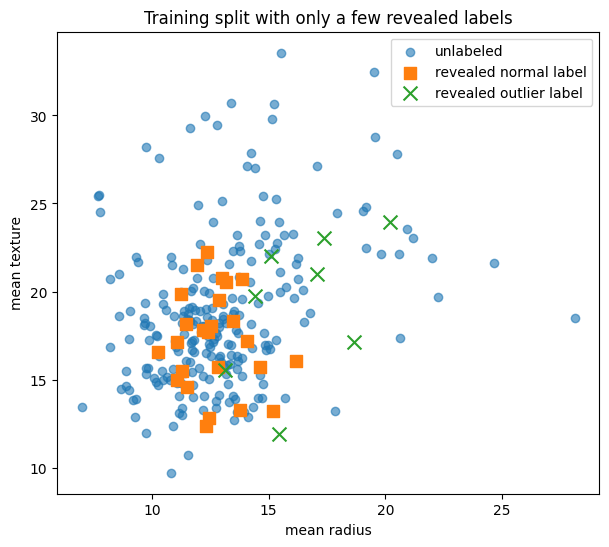

In [4]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_train.loc[semi_y == -1, "mean radius"],
    X_train.loc[semi_y == -1, "mean texture"],
    alpha=0.6,
    label="unlabeled",
)
plt.scatter(
    X_train.loc[semi_y == 0, "mean radius"],
    X_train.loc[semi_y == 0, "mean texture"],
    marker="s",
    s=80,
    label="revealed normal label",
)
plt.scatter(
    X_train.loc[semi_y == 1, "mean radius"],
    X_train.loc[semi_y == 1, "mean texture"],
    marker="x",
    s=100,
    label="revealed outlier label",
)
plt.xlabel("mean radius")
plt.ylabel("mean texture")
plt.title("Training split with only a few revealed labels")
plt.legend()
plt.show()

## 3. Standardize the features

We fit the scaler only on the **training split** to avoid data leakage.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (267, 30)
Validation shape: (89, 30)
Test shape: (90, 30)


## 4. Evaluation helpers
We will report:
- **precision**: among the cases we flag, how many are truly outliers?
- **recall**: among the true outliers, how many do we catch?
- **F1**: a balance between precision and recall,
- **ROC-AUC** and **Average Precision**: how good the raw outlier scores are before applying a threshold.

In [6]:
def evaluate_threshold(y_true, scores, threshold):
    y_pred = (scores >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "average_precision": average_precision_score(y_true, scores),
        "predicted_outliers": int(y_pred.sum()),
    }


def build_review_table(X_raw, y_true, scores, n=10):
    review = X_raw[review_columns].copy()
    review["true_label"] = pd.Series(y_true).map({0: "benign", 1: "malignant"}).to_numpy()
    review["outlier_score"] = scores
    return review.sort_values("outlier_score", ascending=False).head(n)

## 5. Baseline method: plain K-means + centroid distance
We will:
- cluster the data,
- compute the distance from each point to its nearest centroid,
- points with large distances are more likely to be outliers.

In [7]:
def fit_plain_kmeans(X_train_scaled, n_clusters, random_state=RANDOM_STATE):
    model = KMeans(n_clusters=n_clusters, n_init=5, random_state=random_state)
    model.fit(X_train_scaled)
    return model

In [8]:
def score_plain_kmeans(model, X_scaled):
    # Step 1: use model.transform(X_scaled) to get the distance from each sample to every centroid.
    # Step 2: keep only the smallest distance for each sample.
    distances = model.transform(X_scaled)
    return distances.min(axis=1)


In [9]:
example_plain_model = fit_plain_kmeans(X_train_scaled, n_clusters=4)
example_plain_scores = score_plain_kmeans(example_plain_model, X_train_scaled[:5])

assert example_plain_scores.shape == (5,)
assert np.all(example_plain_scores >= 0)
example_plain_scores

array([5.23930202, 2.68476145, 2.43401742, 4.61028916, 3.12652085])

We will tune the baseline on the **validation split** by searching over:

- the number of clusters,
- the threshold quantile computed from the **training scores**.

Example: a threshold quantile of `0.90` means we use the 90th percentile of training scores as the cutoff.

In [10]:
baseline_rows = []

for n_clusters in [3, 4, 5]:
    model = fit_plain_kmeans(X_train_scaled, n_clusters=n_clusters)
    train_scores = score_plain_kmeans(model, X_train_scaled)
    val_scores = score_plain_kmeans(model, X_val_scaled)

    for threshold_quantile in [0.80, 0.85, 0.90]:
        threshold = float(np.quantile(train_scores, threshold_quantile))
        metrics = evaluate_threshold(y_val, val_scores, threshold)
        baseline_rows.append(
            {
                "n_clusters": n_clusters,
                "threshold_quantile": threshold_quantile,
                "threshold": threshold,
                **metrics,
            }
        )

baseline_results = (
    pd.DataFrame(baseline_rows)
    .sort_values(["f1", "average_precision", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(baseline_results.head().round(3))

,n_clusters,threshold_quantile,threshold,precision,recall,f1,roc_auc,average_precision,predicted_outliers
0,4,0.80,4.435,0.524,0.611,0.564,0.788,0.492,21
1,5,0.80,4.417,0.500,0.556,0.526,0.727,0.459,20
2,4,0.85,4.751,0.471,0.444,0.457,0.788,0.492,17
3,3,0.80,4.773,0.444,0.444,0.444,0.749,0.449,18
4,5,0.85,4.670,0.438,0.389,0.412,0.727,0.459,16


In [11]:
best_baseline = baseline_results.iloc[0].to_dict()
best_baseline

{'n_clusters': 4.0,
 'threshold_quantile': 0.8,
 'threshold': 4.434580797972504,
 'precision': 0.5238095238095238,
 'recall': 0.6111111111111112,
 'f1': 0.5641025641025641,
 'roc_auc': 0.7879499217527386,
 'average_precision': 0.4922432832426714,
 'predicted_outliers': 21.0}

## 6. Extend K-means with a simple outlier-cluster rule
After clustering the training data:

- if a **large cluster** contains mostly labeled normal points, treat its unlabeled points as normal,
- if a **small cluster** contains labeled outliers and no labeled normal points, treat its unlabeled points as outliers,
- otherwise leave the cluster **uncertain**.

Then define the final outlier score as:

1. the sample's **distance to its assigned centroid**, adjusted inside its cluster, and
2. a **cluster bonus** when the assigned cluster itself looks suspicious.

In [12]:
def summarize_clusters(cluster_ids, semi_labels):
    rows = []
    n = len(cluster_ids)

    for cluster_id in np.unique(cluster_ids):
        idx = np.where(cluster_ids == cluster_id)[0]
        cluster_labels = semi_labels[idx]

        row = {
            "cluster": int(cluster_id),
            "size": int(len(idx)),
            "size_fraction": len(idx) / n,
            "labeled_normal": int(np.sum(cluster_labels == 0)),
            "labeled_outlier": int(np.sum(cluster_labels == 1)),
            "unlabeled": int(np.sum(cluster_labels == -1)),
        }
        row["labeled_total"] = row["labeled_normal"] + row["labeled_outlier"]

        if row["labeled_total"] > 0:
            row["normal_ratio_labeled"] = row["labeled_normal"] / row["labeled_total"]
            row["outlier_ratio_labeled"] = row["labeled_outlier"] / row["labeled_total"]
        else:
            row["normal_ratio_labeled"] = np.nan
            row["outlier_ratio_labeled"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)

In [13]:
def decide_cluster_role(row, small_cluster_fraction=0.10, large_cluster_fraction=0.15):
    # Return (role, bonus) where role is one of: "normal", "outlier", or "uncertain".
    # 1. small cluster + at least one labeled outlier + no labeled normal -> outlier cluster, bonus 1.6
    # 2. large cluster + mostly labeled normal (or no labels at all)      -> normal cluster, bonus 0.0
    # 3. more labeled outliers than labeled normals                       -> outlier cluster, bonus 1.1
    # 4. otherwise                                                        -> uncertain cluster, bonus 0.5
    is_small = row["size_fraction"] <= small_cluster_fraction
    is_large = row["size_fraction"] >= large_cluster_fraction
    
    if is_small and row["labeled_outlier"] >= 1 and row["labeled_normal"] == 0:
        return "outlier", 1.6
    elif is_large and (row["labeled_normal"] > row["labeled_outlier"] or row["labeled_total"] == 0):
        return "normal", 0.0
    elif row["labeled_outlier"] > row["labeled_normal"]:
        return "outlier", 1.1
    else:
        return "uncertain", 0.5


In [14]:
toy_cluster = {
    "size_fraction": 0.05,
    "labeled_outlier": 2,
    "labeled_normal": 0,
    "labeled_total": 2,
    "normal_ratio_labeled": 0.0,
}
decide_cluster_role(toy_cluster)

('outlier', 1.6)

In [15]:
def fit_semi_supervised_kmeans(
    X_train_scaled,
    semi_labels,
    n_clusters,
    small_cluster_fraction,
    random_state=RANDOM_STATE,
):
    model = KMeans(n_clusters=n_clusters, n_init=5, random_state=random_state)
    train_cluster_ids = model.fit_predict(X_train_scaled)
    cluster_summary = summarize_clusters(train_cluster_ids, semi_labels)

    role_map = {}
    bonus_map = {}
    pseudo_labels = semi_labels.copy()

    for row in cluster_summary.to_dict(orient="records"):
        role, bonus = decide_cluster_role(row, small_cluster_fraction=small_cluster_fraction)
        cluster_id = row["cluster"]
        role_map[cluster_id] = role
        bonus_map[cluster_id] = bonus

        unlabeled_idx = np.where((train_cluster_ids == cluster_id) & (semi_labels == -1))[0]

        # Assign pseudo-labels to the unlabeled points
        if role == "normal":
            pseudo_labels[unlabeled_idx] = 0
        elif role == "outlier":
            pseudo_labels[unlabeled_idx] = 1

    train_distances = model.transform(X_train_scaled).min(axis=1)
    distance_mean = {}
    distance_std = {}

    for cluster_id in np.unique(train_cluster_ids):
        cluster_distances = train_distances[train_cluster_ids == cluster_id]
        distance_mean[cluster_id] = float(cluster_distances.mean())
        distance_std[cluster_id] = float(cluster_distances.std(ddof=0) + 1e-6)

    cluster_summary = cluster_summary.copy()
    cluster_summary["role"] = cluster_summary["cluster"].map(role_map)
    cluster_summary["bonus"] = cluster_summary["cluster"].map(bonus_map)

    return {
        "model": model,
        "cluster_summary": cluster_summary,
        "role_map": role_map,
        "bonus_map": bonus_map,
        "pseudo_labels": pseudo_labels,
        "distance_mean": distance_mean,
        "distance_std": distance_std,
    }

In [16]:
example_detector = fit_semi_supervised_kmeans(
    X_train_scaled,
    semi_labels=semi_y,
    n_clusters=4,
    small_cluster_fraction=0.10,
)

pseudo_label_counts = (
    pd.Series(example_detector["pseudo_labels"])
    .map({-1: "still unlabeled", 0: "pseudo-labeled normal", 1: "pseudo-labeled outlier"})
    .value_counts()
    .rename_axis("pseudo_label_status")
    .to_frame("count")
)

display(example_detector["cluster_summary"].round(3))
display(pseudo_label_counts)

,cluster,size,size_fraction,labeled_normal,labeled_outlier,unlabeled,labeled_total,normal_ratio_labeled,outlier_ratio_labeled,role,bonus
0,0,131,0.491,14,2,115,16,0.875,0.125,normal,0.0
1,1,20,0.075,0,2,18,2,0.000,1.000,outlier,1.6
2,2,32,0.120,0,3,29,3,0.000,1.000,outlier,1.1
3,3,84,0.315,11,1,72,12,0.917,0.083,normal,0.0


,count
pseudo_label_status,
pseudo-labeled normal,212
pseudo-labeled outlier,55


In [17]:
def score_semi_supervised_kmeans(detector, X_scaled):
    model = detector["model"]
    cluster_ids = model.predict(X_scaled)
    distance_matrix = model.transform(X_scaled)
    nearest_distances = distance_matrix[np.arange(len(X_scaled)), cluster_ids]

    # Step 1: convert each nearest-centroid distance into a within-cluster z-score
    # Step 2: clip negative z-scores to 0
    # Step 3: add the cluster bonus for the assigned cluster
    
    cluster_means = np.array([detector["distance_mean"][cid] for cid in cluster_ids])
    cluster_stds = np.array([detector["distance_std"][cid] for cid in cluster_ids])
    cluster_bonuses = np.array([detector["bonus_map"][cid] for cid in cluster_ids])
    
    z_scores = (nearest_distances - cluster_means) / cluster_stds
    z_scores = np.clip(z_scores, 0, None)
    
    return z_scores + cluster_bonuses


In [18]:
example_semi_scores = score_semi_supervised_kmeans(example_detector, X_train_scaled[:5])
assert example_semi_scores.shape == (5,)
example_semi_scores

array([1.95139547, 0.        , 0.        , 1.39829549, 1.6       ])

Now tune the semi-supervised detector on the **validation split**.

In [19]:
semi_rows = []

for n_clusters in [3, 4, 5]:
    for small_cluster_fraction in [0.08, 0.10, 0.12]:
        detector = fit_semi_supervised_kmeans(
            X_train_scaled,
            semi_labels=semi_y,
            n_clusters=n_clusters,
            small_cluster_fraction=small_cluster_fraction,
        )
        train_scores = score_semi_supervised_kmeans(detector, X_train_scaled)
        val_scores = score_semi_supervised_kmeans(detector, X_val_scaled)

        for threshold_quantile in [0.80, 0.85, 0.90]:
            threshold = float(np.quantile(train_scores, threshold_quantile))
            metrics = evaluate_threshold(y_val, val_scores, threshold)
            semi_rows.append(
                {
                    "n_clusters": n_clusters,
                    "small_cluster_fraction": small_cluster_fraction,
                    "threshold_quantile": threshold_quantile,
                    "threshold": threshold,
                    **metrics,
                }
            )

semi_results = (
    pd.DataFrame(semi_rows)
    .sort_values(["f1", "average_precision", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(semi_results.head().round(3))

,n_clusters,small_cluster_fraction,threshold_quantile,threshold,precision,recall,f1,roc_auc,average_precision,predicted_outliers
0,4,0.12,0.80,1.6,0.636,0.778,0.700,0.861,0.620,22
1,4,0.12,0.85,1.6,0.636,0.778,0.700,0.861,0.620,22
2,5,0.10,0.80,1.6,0.577,0.833,0.682,0.838,0.564,26
3,5,0.10,0.85,1.6,0.577,0.833,0.682,0.838,0.564,26
4,5,0.12,0.80,1.6,0.577,0.833,0.682,0.838,0.564,26


In [20]:
best_semi = semi_results.iloc[0].to_dict()

best_semi_detector = fit_semi_supervised_kmeans(
    X_train_scaled,
    semi_labels=semi_y,
    n_clusters=int(best_semi["n_clusters"]),
    small_cluster_fraction=float(best_semi["small_cluster_fraction"]),
)

best_semi

{'n_clusters': 4.0,
 'small_cluster_fraction': 0.12,
 'threshold_quantile': 0.8,
 'threshold': 1.6,
 'precision': 0.6363636363636364,
 'recall': 0.7777777777777778,
 'f1': 0.7,
 'roc_auc': 0.8607198748043818,
 'average_precision': 0.6200883014404955,
 'predicted_outliers': 22.0}

In [21]:
pseudo_label_counts = (
    pd.Series(best_semi_detector["pseudo_labels"])
    .map({-1: "still unlabeled", 0: "pseudo-labeled normal", 1: "pseudo-labeled outlier"})
    .value_counts()
    .rename_axis("pseudo_label_status")
    .to_frame("count")
)

hidden_mask = semi_y == -1
pseudo_label_accuracy = (
    best_semi_detector["pseudo_labels"][hidden_mask] == y_train.to_numpy()[hidden_mask]
).mean()

display(best_semi_detector["cluster_summary"].round(3))
display(pseudo_label_counts)
print("Agreement with the hidden training labels (teaching check only, not final test performance): "
      f"{pseudo_label_accuracy:.3f}")

,cluster,size,size_fraction,labeled_normal,labeled_outlier,unlabeled,labeled_total,normal_ratio_labeled,outlier_ratio_labeled,role,bonus
0,0,131,0.491,14,2,115,16,0.875,0.125,normal,0.0
1,1,20,0.075,0,2,18,2,0.000,1.000,outlier,1.6
2,2,32,0.120,0,3,29,3,0.000,1.000,outlier,1.6
3,3,84,0.315,11,1,72,12,0.917,0.083,normal,0.0


,count
pseudo_label_status,
pseudo-labeled normal,212
pseudo-labeled outlier,55


Agreement with the hidden training labels (teaching check only, not final test performance): 0.915


## 7. Final evaluation on the test split

Only after choosing the best settings on the **validation split** do we evaluate once on the **test split**.

In [22]:
baseline_model = fit_plain_kmeans(X_train_scaled, n_clusters=int(best_baseline["n_clusters"]))
baseline_test_scores = score_plain_kmeans(baseline_model, X_test_scaled)
baseline_test_threshold = float(best_baseline["threshold"])
baseline_test_pred = (baseline_test_scores >= baseline_test_threshold).astype(int)
baseline_test_metrics = evaluate_threshold(y_test, baseline_test_scores, baseline_test_threshold)

semi_test_scores = score_semi_supervised_kmeans(best_semi_detector, X_test_scaled)
semi_test_threshold = float(best_semi["threshold"])
semi_test_pred = (semi_test_scores >= semi_test_threshold).astype(int)
semi_test_metrics = evaluate_threshold(y_test, semi_test_scores, semi_test_threshold)

comparison = pd.DataFrame(
    [
        {"method": "K-means distance baseline", **baseline_test_metrics},
        {"method": "Semi-supervised K-means + cluster rule", **semi_test_metrics},
    ]
)

display(comparison.round(3))

,method,precision,recall,f1,roc_auc,average_precision,predicted_outliers
0,K-means distance baseline,0.333,0.333,0.333,0.674,0.357,18
1,Semi-supervised K-means + cluster rule,0.727,0.889,0.800,0.910,0.666,22


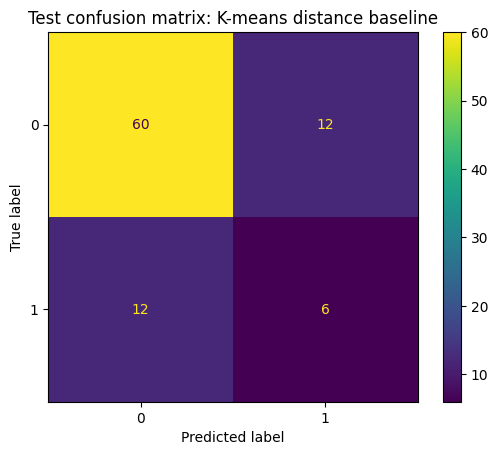

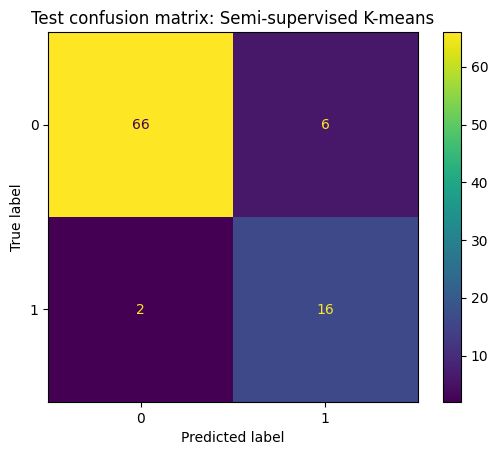

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, baseline_test_pred)
plt.title("Test confusion matrix: K-means distance baseline")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, semi_test_pred)
plt.title("Test confusion matrix: Semi-supervised K-means")
plt.show()

## 8. Which test cases would be reviewed first?

The next table shows the highest-scoring test cases under the semi-supervised model.
In a real workflow, these would be the first records sent to a human reviewer.

In [24]:
display(build_review_table(X_test, y_test, semi_test_scores, n=10).round(3))

,mean radius,mean texture,mean area,worst perimeter,worst concavity,true_label,outlier_score
413,17.950,20.01,982.0,129.20,0.225,malignant,4.021
338,11.200,29.37,386.0,75.19,0.000,benign,3.958
27,14.410,19.73,651.0,101.70,0.222,benign,2.855
432,9.676,13.14,272.5,69.47,0.291,benign,2.624
417,18.310,18.58,1041.0,139.20,0.354,malignant,2.173
99,17.190,22.07,928.3,140.50,0.389,malignant,1.731
181,17.540,19.32,951.6,139.50,0.351,malignant,1.634
278,19.790,25.12,1192.0,148.70,0.567,malignant,1.600
30,17.470,24.68,984.6,155.30,0.489,malignant,1.600
104,20.470,20.67,1299.0,152.00,0.309,malignant,1.600


## 9. Discussion questions

Write short answers for the following:

1. Why do we choose the threshold and hyperparameters on the **validation split** instead of on the **test split**?
2. Why can an outlier detector work well on one test set but still fail on future outliers?
3. When is the **small-cluster rule** useful? When might it create false alarms?

In [25]:
# 1. Why do we choose the threshold and hyperparameters on the validation split instead of on the test split?
# Checking on the validation split prevents data leakage. The test split is meant to simulate strictly unseen data. If we tune hyperparameters or thresholds on the test split, the model implicitly learns the test set's distribution (overfitting), which leads to overly optimistic performance estimations.

# 2. Why can an outlier detector work well on one test set but still fail on future outliers?
# Outliers are rare anomalies, and future outliers might take on completely new, unpredictable forms. An algorithm tuned to detect historical anomalies (present in your test set) might not be generalized enough to catch completely novel deviations or structural shifts in the data.

# 3. When is the small-cluster rule useful? When might it create false alarms?
# It is useful when anomalies naturally group together (e.g., a localized hardware failure that produces a consistent cluster of bad readings rather than widely scattered points). However, it creates false alarms if a small cluster is simply an underrepresented sub-population of normal behavior, a natural data perturbation, or just noise that the K-Means algorithm incorrectly isolated.


## 1. Why do we choose the threshold and hyperparameters on the validation split instead of on the test split?

Checking on the validation split prevents **data leakage**. The test split is meant to simulate strictly unseen data—the "final exam" for your model. 

If we tune hyperparameters or thresholds on the test split, the model implicitly learns the test set's specific distribution. This leads to **overfitting** to that specific data slice, which results in overly optimistic performance estimations that likely won't hold up in the real world.



---

## 2. Why can an outlier detector work well on one test set but still fail on future outliers?

Outliers are, by definition, rare anomalies. The "black swan" theory applies here: future outliers might take on **completely new, unpredictable forms** that haven't been seen before. 

An algorithm tuned to detect historical anomalies (those present in your current test set) might not be generalized enough to catch:
* **Novel deviations:** New ways for a system to fail.
* **Structural shifts:** Changes in what constitutes "normal" behavior over time (concept drift).
* **Adaptive adversaries:** In security, attackers often change their patterns once they know they're being detected.

---

## 3. When is the small-cluster rule useful? When might it create false alarms?

The small-cluster rule assumes that if a group of points is significantly smaller and farther away than other clusters, it likely represents an anomaly.

### **When it is useful:**
* **Grouped Anomalies:** It's perfect for when anomalies naturally group together, such as a localized hardware failure producing a consistent cluster of "bad" readings rather than scattered noise.
* **Systemic Issues:** Identifying specific batches of faulty products in manufacturing.

### **When it creates false alarms:**
* **Underrepresented Sub-populations:** A small cluster might just be a rare but **normal** demographic or behavior that hasn't been sampled heavily.
* **Data Noise:** Random perturbations that the K-Means algorithm incorrectly isolated.
* **Niche Cases:** In high-dimensional data, "normal" points can often look like small, isolated islands.

## End of lab

You now have two detectors:
- a plain K-means outlier detector,
- an extended K-means detector that uses **semi-supervised labels** and a simple **outlier-cluster rule**.

We followed the key lecture ideas:
- clustering-based outlier detection,
- semi-supervised labeling inside clusters,
- evaluation with separate **train**, **validation**, and **test** splits.